# CN7·RG3 정상 관계식과 잔차 학습

**질문:** 다른 공정값으로 예상한 값과 실제 값의 어긋남이 위험 판별에 도움이 되는가?

정상 관계식의 예측력과 불량 판별력을 별도로 확인합니다. 기존 자료를 관찰한 후속 실험이며, 현장 효과를 확정하지 않습니다.

이 노트북은 기본적으로 이미 실행한 결과를 읽습니다. 아래 코드에는 전체 파이프라인의 사본이 포함되어 있습니다. 새 실험을 실행하려면 설정 셀을 변경하세요. 기존 결과 폴더는 덮어쓰지 않습니다.

## 1. 실행 가능한 전체 파이프라인

각 fold의 정상 참조 패턴과 분류기 학습 패턴을 분리합니다. 관계식은 자기 자신의 현재값을 입력으로 쓰지 않습니다. 참조 정상 OOF R²로 관계를 선별하고, 개발 validation에서 후보와 임계값을 정합니다.

`raw_full`은 전체 학습 자료 기준선, `raw_matched`는 잔차 모델과 동일한 지도학습 행 기준선입니다. 시간 실험은 원본 순서 가정 아래 과거 3행 정보를 사용하며, 패턴 실험과 정답의 의미가 다릅니다.

In [1]:
"""KAMP normal-relationship residual experiment.

Run: python modeling/relationship_residual_pipeline.py --run-id <new-name>
No changes to original data, previous notebooks, splits or outputs.
Definitions: normal-relationship reference, classifier-training, validation and
test roles are separated. No test-driven feature/threshold/model selection.
"""
from __future__ import annotations

import argparse
import hashlib
import json
import os
from pathlib import Path
import platform
import sys
import time

ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p/'kamp_data').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(ROOT/'tmp/matplotlib_cache'))
os.environ.setdefault('OMP_NUM_THREADS', '1')

import joblib
import numpy as np
import pandas as pd
import scipy
from scipy.stats import beta
import sklearn
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, r2_score, roc_auc_score)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CONFIG = dict(seed=42, relation_reference_normal_fraction=0.5,
              relation_inner_folds=3, relation_min_oof_r2=0.2,
              ridge_alpha=10., extra_trees=32, extra_depth=5, extra_min_leaf=8,
              logistic_C=1., rf_trees=128, rf_depth=5, rf_min_leaf=5,
              past_window=3, temporal_gap=3,
              threshold_rule='pooled validation F1; ties fewer FP, higher threshold',
              pattern_target='any observed defect in exact current-input pattern',
              temporal_target='original row label; file order assumed temporal',
              status='follow-up exploration on previously inspected data')

def digest(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()

def write_json(p, value):
    Path(p).write_text(json.dumps(value, ensure_ascii=False, indent=2,
                                  default=lambda v: v.item() if isinstance(v,np.generic) else str(v)), encoding='utf-8')

def counts(y, score, threshold):
    y=np.asarray(y,dtype=int); score=np.asarray(score,dtype=float)
    assert np.isfinite(score).all()
    pred=(score > threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    p=int(y.sum()); n=len(y)-p
    return dict(n=len(y), positives=p, TP=int(tp),FP=int(fp),FN=int(fn),TN=int(tn),
                precision=float(tp/(tp+fp)) if tp+fp else 0.,
                recall=float(tp/p) if p else None,
                FPR=float(fp/n) if n else None,
                F1=float(2*tp/(2*tp+fp+fn)) if 2*tp+fp+fn else 0.,
                AP=float(average_precision_score(y,score)) if p else None,
                AUC=float(roc_auc_score(y,score)) if p and n else None)

def choose_threshold(y, score):
    y=np.asarray(y,dtype=int); score=np.asarray(score,dtype=float)
    assert 0 < y.sum() < len(y)
    order=np.argsort(-score,kind='stable'); ss=score[order]; yy=y[order]
    ends=np.r_[np.flatnonzero(np.diff(ss)),len(ss)-1]
    tp=np.cumsum(yy)[ends]; fp=ends+1-tp; fn=y.sum()-tp
    f1=2*tp/(2*tp+fp+fn)
    # A cutoff just below an observed score includes that entire tie group.
    thresholds=np.nextafter(ss[ends],-np.inf)
    i=sorted(range(len(ends)),key=lambda j:(-f1[j],fp[j],-thresholds[j]))[0]
    return float(thresholds[i])

def group_codes(x):
    return pd.factorize(pd.Series(list(map(tuple,x.to_numpy()))))[0]

def reference_roles(x, y, groups):
    """Keep mixed-label groups out of the normal reference entirely."""
    group_label=pd.Series(np.asarray(y)).groupby(groups).max()
    normal=group_label.index[group_label.eq(0)].to_numpy().copy()
    rng=np.random.default_rng(CONFIG['seed']); rng.shuffle(normal)
    selected=normal[:max(3,int(len(normal)*CONFIG['relation_reference_normal_fraction']))]
    reference=np.flatnonzero(np.isin(groups,selected))
    classifier=np.flatnonzero(~np.isin(groups,selected))
    assert len(set(groups[reference]) & set(groups[classifier]))==0
    assert np.all(np.asarray(y)[reference]==0)
    assert len(np.unique(np.asarray(y)[classifier]))==2
    return reference,classifier

def regression(backend):
    if backend=='ridge':
        return make_pipeline(StandardScaler(),Ridge(alpha=CONFIG['ridge_alpha']))
    return ExtraTreesRegressor(n_estimators=CONFIG['extra_trees'],max_depth=CONFIG['extra_depth'],
                               min_samples_leaf=CONFIG['extra_min_leaf'],random_state=42,n_jobs=1)

class RelationshipBank:
    """One regression per current variable; never use the target as predictor.

    OOF prediction on normal reference measures relationship learnability.
    Retain targets with fixed R2 >= .2. Residual scale is OOF normal Q90(abs error)
    with 5% of normal target SD floor. Classifier rows are never reference rows.
    """
    def __init__(self,backend):
        self.backend=backend

    def fit(self, context, current, groups):
        self.models={}; self.records=[]; self.targets=[]; self.context_columns=list(context)
        folds=list(GroupKFold(n_splits=3).split(context,groups=groups))
        for target in current:
            yy=current[target].to_numpy()
            if np.std(yy)<1e-12:
                self.records.append(dict(target=target,retained=False,reason='constant_reference_target',oof_r2=None))
                continue
            predictors=[c for c in context if c!=target and context[c].nunique()>1]
            assert target not in predictors
            if not predictors:
                continue
            oof=np.full(len(yy),np.nan)
            for tr,va in folds:
                assert not (set(groups[tr])&set(groups[va]))
                reg=regression(self.backend).fit(context.iloc[tr][predictors],yy[tr])
                oof[va]=reg.predict(context.iloc[va][predictors])
            assert np.isfinite(oof).all()
            quality=float(r2_score(yy,oof))
            scale=max(float(np.quantile(np.abs(yy-oof),.9)),float(np.std(yy))*.05,1e-8)
            record=dict(target=target,retained=quality>=CONFIG['relation_min_oof_r2'],
                        reason='retained' if quality>=CONFIG['relation_min_oof_r2'] else 'weak_normal_relationship',
                        oof_r2=quality,oof_mae=float(np.mean(np.abs(yy-oof))),residual_scale=scale,
                        predictor_count=len(predictors),normal_reference_rows=len(yy))
            self.records.append(record)
            if record['retained']:
                model=regression(self.backend).fit(context[predictors],yy)
                self.models[target]=dict(model=model,predictors=predictors,scale=scale)
                self.targets.append(target)
        return self

    def residuals(self, context, current):
        result=pd.DataFrame(index=context.index)
        for target in self.targets:
            item=self.models[target]
            result[target]=(current[target]-item['model'].predict(context[item['predictors']]))/item['scale']
        return result

    def features(self, context, current):
        residual=self.residuals(context,current)
        if not len(residual.columns):
            return pd.DataFrame({'no_retained_relationship':np.zeros(len(context))},index=context.index)
        a=residual.abs().to_numpy(); k=min(3,a.shape[1])
        return pd.concat([residual.add_prefix('residual::'),residual.abs().add_prefix('abs_residual::'),
            pd.DataFrame({'residual_mean':a.mean(axis=1),'residual_max':a.max(axis=1),
                          'residual_top3_mean':np.sort(a,axis=1)[:,-k:].mean(axis=1)},index=context.index)],axis=1)

def classifier(kind):
    if kind=='lr':
        return make_pipeline(StandardScaler(),LogisticRegression(C=1.,class_weight='balanced',
                                                                 max_iter=3000,random_state=42))
    return RandomForestClassifier(n_estimators=128,max_depth=5,min_samples_leaf=5,
                                   class_weight='balanced',max_features='sqrt',random_state=42,n_jobs=1)

class RelationshipExperiment:
    def fit(self,context,current,y,groups):
        ref,cl=reference_roles(current,y,groups)
        self.reference=ref; self.classifier_rows=cl; self.banks={}; self.models={}; self.specs={}
        self.fit_inputs=list(context); y=np.asarray(y)
        for kind in ('lr','rf'):
            for scope,indices in [('full',np.arange(len(y))),('matched',cl)]:
                name=f'raw_{scope}_{kind}'
                self.models[name]=classifier(kind).fit(context.iloc[indices],y[indices])
                self.specs[name]=dict(representation='raw',backend=None,kind=kind,columns=list(context))
        for backend in ('ridge','extra'):
            bank=RelationshipBank(backend).fit(context.iloc[ref].reset_index(drop=True),
                current.iloc[ref].reset_index(drop=True),groups[ref])
            self.banks[backend]=bank
            residual=bank.features(context,current)
            for representation,frame,kinds in [('residual',residual,('lr',)),
                                                ('augmented',pd.concat([context,residual],axis=1),('lr','rf'))]:
                for kind in kinds:
                    name=f'{backend}_{representation}_{kind}'
                    self.models[name]=classifier(kind).fit(frame.iloc[cl],y[cl])
                    self.specs[name]=dict(representation=representation,backend=backend,kind=kind,columns=list(frame))
        return self

    def predict(self,context,current):
        output={}; frames={b:bank.features(context,current) for b,bank in self.banks.items()}
        for name,model in self.models.items():
            spec=self.specs[name]; frame=context
            if spec['representation']=='residual': frame=frames[spec['backend']]
            elif spec['representation']=='augmented': frame=pd.concat([context,frames[spec['backend']]],axis=1)
            assert list(frame)==spec['columns']
            output[name]=model.predict_proba(frame)[:,list(model.classes_).index(1)]
        for backend,frame in frames.items():
            output[f'{backend}_unsupervised_top3']=frame.get('residual_top3_mean',pd.Series(np.zeros(len(frame)),index=frame.index)).to_numpy()
        return output

def load_pattern(ds):
    base=ROOT/f'data/processed/{ds}/conservative'
    manifest=json.loads((base/'splits/split_manifest.json').read_text(encoding='utf-8'))
    for name,expected in manifest['source_sha256'].items():
        assert digest(base/name)==expected, f'Changed source: {name}'
    assert digest(base/'splits/split_assignments.csv')==manifest['artifact_sha256']['split_assignments.csv']
    x=pd.read_csv(base/'X_labeled.csv',float_precision='round_trip')
    y=pd.read_csv(base/'y_labeled.csv').PassOrFail.to_numpy()
    assign=pd.read_csv(base/'splits/split_assignments.csv')
    assert np.array_equal(assign.pattern_row,np.arange(len(x))) and np.array_equal(assign.label,y)
    raw=pd.read_csv(ROOT/f'kamp_data/moldset_labeled_{ds}.csv',float_precision='round_trip')
    agg=raw.groupby(list(x),sort=False,dropna=False).PassOrFail.max()
    expected=pd.DataFrame(list(agg.index),columns=x.columns)
    assert np.array_equal(expected.to_numpy(),x.to_numpy()) and np.array_equal(agg.to_numpy(),y)
    dev=np.flatnonzero(assign.partition.eq('development')); test=np.flatnonzero(assign.partition.eq('test'))
    folds=[]
    for f in sorted(assign.loc[dev,'cv_fold'].unique()):
        va=dev[assign.loc[dev,'cv_fold'].to_numpy()==f]
        tr=dev[assign.loc[dev,'cv_fold'].to_numpy()!=f]
        folds.append((f'train_fold_{f}',tr,va))
    return x,x.copy(),y,group_codes(x),dev,test,folds,dict(protocol='fixed_pattern',dataset=ds,
        target=CONFIG['pattern_target'],source_sha256=digest(ROOT/f'kamp_data/moldset_labeled_{ds}.csv'))

def past_context(x,window=3):
    # Current target remains separate. Its own lag is a permitted past predictor.
    return pd.concat([x,x.shift(1).add_prefix('lag1::'),
                      x.shift(1).rolling(window,min_periods=window).mean().add_prefix('past3mean::'),
                      x.shift(1).rolling(window,min_periods=window).std(ddof=0).add_prefix('past3std::')],axis=1)

def load_temporal(ds):
    raw=pd.read_csv(ROOT/f'kamp_data/moldset_labeled_{ds}.csv',float_precision='round_trip')
    x=raw.drop(columns=['Unnamed: 0','PassOrFail']); y=raw.PassOrFail.to_numpy(); n=len(x)
    keys=list(map(tuple,x.to_numpy())); last={k:i for i,k in enumerate(keys)}
    def boundary(b):
        while max(last[k] for k in keys[:b])+1>b:
            b=max(last[k] for k in keys[:b])+1
        return b
    a=boundary(int(.6*n)); b=boundary(int(.8*n)); window=CONFIG['past_window']; gap=CONFIG['temporal_gap']
    tr=np.arange(window,a); va=np.arange(a+gap,b); te=np.arange(b+gap,n)
    groups=group_codes(x)
    assert not(set(groups[tr])&set(groups[va])) and not(set(groups[tr])&set(groups[te]))
    assert tr.max()<va.min() and va.max()<te.min()
    context=past_context(x,window)
    assert np.isfinite(context.iloc[np.r_[tr,va,te]].to_numpy()).all()
    info=dict(protocol='temporal_assumed',dataset=ds,target=CONFIG['temporal_target'],
              first_validation_row_1based=int(va[0]+1),first_test_row_1based=int(te[0]+1),
              gap=gap,split_counts=[len(tr),len(va),len(te)],split_defects=[int(y[i].sum()) for i in (tr,va,te)])
    return context,x,y,groups,tr,te,[('forward_validation',tr,va)],info

def normal_generalization(bank,context,current,y):
    out=[]; normal=np.asarray(y)==0
    for target in bank.targets:
        item=bank.models[target]; actual=current.loc[normal,target].to_numpy()
        predicted=item['model'].predict(context.loc[normal,item['predictors']])
        out.append(dict(target=target,normal_rows=len(actual),
                        normal_r2=float(r2_score(actual,predicted)) if len(actual)>1 and np.std(actual)>1e-12 else None,
                        normal_mae=float(np.mean(np.abs(actual-predicted)))))
    return out

def run_protocol(ds,protocol,out):
    out.mkdir(parents=True,exist_ok=False)
    context,current,y,groups,dev,test,folds,info=(load_pattern(ds) if protocol=='fixed_pattern' else load_temporal(ds))
    if protocol=='temporal_assumed' and any(len(np.unique(y[ix]))<2 for _,tr,va in folds for ix in (tr,va)):
        info['status']='not_evaluable: future validation contains no defects; no future defect detection claim'
        write_json(out/'protocol.json',info); print(ds,protocol,'SKIP: no future validation defects',flush=True)
        return info
    write_json(out/'protocol.json',info)
    validation_parts=[]; relation_records=[]; roles=[]; frozen_experiment=None
    for tag,tr,va in folds:
        print(ds,protocol,tag,'fit',len(tr),'validate',len(va),flush=True)
        assert not(set(groups[tr])&set(groups[va]))
        exp=RelationshipExperiment().fit(context.iloc[tr].reset_index(drop=True),current.iloc[tr].reset_index(drop=True),y[tr],groups[tr])
        roles.append(dict(fold=tag,reference_rows=tr[exp.reference].tolist(),classifier_rows=tr[exp.classifier_rows].tolist(),
                          validation_rows=va.tolist(),train_rows=tr.tolist()))
        scores=exp.predict(context.iloc[va].reset_index(drop=True),current.iloc[va].reset_index(drop=True))
        for name,s in scores.items():
            validation_parts.append(pd.DataFrame({'row':va,'fold':tag,'model':name,'y':y[va],'score':s}))
        for backend,bank in exp.banks.items():
            relation_records.extend([dict(fold=tag,backend=backend,**r) for r in bank.records])
        if protocol=='temporal_assumed': frozen_experiment=exp
    predictions=pd.concat(validation_parts,ignore_index=True)
    predictions.to_csv(out/'validation_predictions.csv',index=False)
    write_json(out/'role_plan.json',roles)
    pd.DataFrame(relation_records).to_csv(out/'relationship_oof_quality.csv',index=False)
    thresholds={}; selected_rows=[]
    for name,part in predictions.groupby('model'):
        assert part.row.is_unique
        t=choose_threshold(part.y,part.score); thresholds[name]=t
        selected_rows.append(dict(model=name,threshold=t,**counts(part.y,part.score,t)))
    comparison=pd.DataFrame(selected_rows).sort_values(['F1','FP','model'],ascending=[False,True,True])
    comparison.to_csv(out/'validation_comparison.csv',index=False)
    choice=comparison.iloc[0].to_dict()
    write_json(out/'selection_manifest.json',dict(selected=choice,thresholds=thresholds,test_used_for_selection=False,
        final_fit='development refit' if protocol=='fixed_pattern' else 'keep train-only model and validation threshold',config=CONFIG))
    selection_digest=digest(out/'selection_manifest.json')
    if frozen_experiment is None:
        print(ds,protocol,'final fit',len(dev),flush=True)
        exp=RelationshipExperiment().fit(context.iloc[dev].reset_index(drop=True),current.iloc[dev].reset_index(drop=True),y[dev],groups[dev])
    else:
        exp=frozen_experiment
    write_json(out/'final_fit_roles.json',dict(reference_rows=dev[exp.reference].tolist(),classifier_rows=dev[exp.classifier_rows].tolist(),test_rows=test.tolist()))
    joblib.dump(exp,out/'experiment.joblib')
    ctx=context.iloc[test].reset_index(drop=True); cur=current.iloc[test].reset_index(drop=True)
    scores=exp.predict(ctx,cur); reloaded=joblib.load(out/'experiment.joblib').predict(ctx,cur)
    assert all(np.allclose(scores[k],reloaded[k],atol=1e-12,rtol=0) for k in scores)
    test_rows=[]; test_predictions=[]; normal_records=[]; topk=[]; explanations=[]
    for name,s in scores.items():
        t=thresholds[name]; test_rows.append(dict(model=name,selected_on_validation=name==choice['model'],threshold=t,**counts(y[test],s,t)))
        test_predictions.append(pd.DataFrame({'row':test,'model':name,'y':y[test],'score':s,'threshold':t,'prediction':(s>t).astype(int)}))
        for fraction in (.1,.2,.3):
            k=int(np.ceil(len(test)*fraction)); cutoff=np.sort(s)[-k]
            greater=s>cutoff; equal=s==cutoff; seats=k-int(greater.sum())
            guaranteed=int(y[test][greater].sum()); tied_bad=int(y[test][equal].sum()); tied_n=int(equal.sum())
            topk.append(dict(model=name,fraction=fraction,k=k,
                expected_TP_random_ties=guaranteed+seats*tied_bad/tied_n,
                min_TP_with_ties=guaranteed+max(0,seats-(tied_n-tied_bad)),
                max_TP_with_ties=guaranteed+min(seats,tied_bad),total_defects=int(y[test].sum())))
    for backend,bank in exp.banks.items():
        pd.DataFrame(bank.records).to_csv(out/f'{backend}_final_relationships.csv',index=False)
        normal_records.extend([dict(backend=backend,**r) for r in normal_generalization(bank,ctx,cur,y[test])])
        residual=bank.residuals(ctx,cur)
        for i in range(len(test)):
            for target in residual.iloc[i].abs().sort_values(ascending=False).head(3).index:
                item=bank.models[target]; observed=float(cur.loc[i,target]); r=float(residual.loc[i,target])
                explanations.append(dict(row=int(test[i]),label=int(y[test[i]]),backend=backend,target=target,
                    observed=observed,expected=observed-r*item['scale'],scaled_residual=r,
                    meaning='relationship deviation, NOT causal attribution or defect probability'))
    pd.DataFrame(test_rows).to_csv(out/'test_comparison.csv',index=False)
    pd.concat(test_predictions).to_csv(out/'test_predictions.csv',index=False)
    pd.DataFrame(topk).to_csv(out/'test_topk_tie_aware.csv',index=False)
    pd.DataFrame(normal_records).to_csv(out/'test_normal_relationship_quality.csv',index=False)
    pd.DataFrame(explanations).to_csv(out/'test_residual_explanations.csv',index=False)
    # Export executable standardized linear relationship equations, not physical laws.
    equations=[]
    for target,item in exp.banks['ridge'].models.items():
        scaler,reg=item['model'].steps[0][1],item['model'].steps[1][1]
        equations.append(dict(target=target,intercept=float(reg.intercept_),
            terms=[dict(predictor=c,coefficient=float(co),center=float(mu),scale=float(sd))
                   for c,co,mu,sd in zip(item['predictors'],reg.coef_,scaler.mean_,scaler.scale_)],
            equation='predicted target = intercept + sum(coefficient * (predictor - center) / scale)'))
    write_json(out/'linear_relationship_equations.json',equations)
    assert digest(out/'selection_manifest.json')==selection_digest
    chosen=next(r for r in test_rows if r['selected_on_validation'])
    tp,p=chosen['TP'],chosen['positives']
    ci=[float(beta.ppf(.025,tp,p-tp+1)) if tp else 0.,float(beta.ppf(.975,tp+1,p-tp)) if tp<p else 1.] if p else None
    report=dict(**info,status='completed',validation_selected=choice['model'],
        validation_F1=choice['F1'],test=chosen,recall_binomial_95_interval=ci,
        interval_note='descriptive exact-binomial interval; independence may fail, selection/data shift not covered',
        selection_frozen_before_test=True,model_reload_identical=True,
        retained_relations={b:len(bank.targets) for b,bank in exp.banks.items()},
        test_role='previously inspected follow-up; no deployment claim')
    write_json(out/'verification.json',report)
    print(ds,protocol,'SELECTED',choice['model'],'validation F1',round(choice['F1'],4),
          'test',chosen['TP'],chosen['FP'],chosen['FN'],flush=True)
    return report

def figures(out):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    for folder in sorted(p for p in out.iterdir() if p.is_dir() and (p/'test_comparison.csv').exists()):
        test=pd.read_csv(folder/'test_comparison.csv').set_index('model')
        val=pd.read_csv(folder/'validation_comparison.csv').set_index('model')
        names=list(test.index); yy=np.arange(len(names))
        fig,ax=plt.subplots(figsize=(11,6))
        ax.barh(yy-.18,val.loc[names,'F1'],height=.36,label='Validation (selection)')
        ax.barh(yy+.18,test.loc[names,'F1'],height=.36,label='Test (follow-up)')
        ax.set_yticks(yy,names); ax.set_xlabel('F1');ax.set_title(folder.name+' | fixed model settings');ax.legend()
        fig.tight_layout();fig.savefig(folder/'comparison.png',dpi=150);plt.close(fig)
        quality=pd.read_csv(folder/'relationship_oof_quality.csv')
        pivot=quality.pivot_table(index='target',columns='backend',values='oof_r2',aggfunc='median').clip(-1,1)
        fig,ax=plt.subplots(figsize=(8,8));im=ax.imshow(pivot.to_numpy(),vmin=-1,vmax=1,cmap='RdYlGn',aspect='auto')
        ax.set_yticks(range(len(pivot)),pivot.index,fontsize=8);ax.set_xticks(range(len(pivot.columns)),pivot.columns)
        ax.set_title(folder.name+' | normal-reference OOF R2');fig.colorbar(im,ax=ax)
        fig.tight_layout();fig.savefig(folder/'relationship_quality.png',dpi=140);plt.close(fig)

def summary_text(out,reports):
    lines=['KAMP 정상 관계식·잔차 학습 실험 결과','',
           '가설: 불량은 단일 값의 극단성보다 정상 공정 변수 관계의 어긋남으로 구별될 수 있는가?',
           '설계: 정상 참조 패턴 50%로 관계식 학습, 나머지 정상 및 위험으로 분류기 학습.',
           '관계식 대상: 현재 변수 하나를 나머지 변수로 예측. 시간 실험은 이전 값·과거 3행 요약을 추가.',
           '선형 Ridge와 비선형 ExtraTrees 비교. 참조 정상 내부 3-fold OOF R² >= 0.2인 관계만 사용.',
           '잔차: (실제값 - 예측값) / 정상 OOF 절대오차 90% 분위수(최소 척도 적용).',
           '분류기: 고정 설정 LR/RF. 모든 설정은 config.json에 기록. 검증 F1로 임계값·후보 선택.',
           'raw_full은 모든 학습행, raw_matched는 잔차 분류기와 같은 학습행 사용.',
           '패턴 실험은 기존 고정 분할과 위험 이력 목표 유지. 시간 실험은 원본 행 라벨로 별도 평가.',
           'CN7 시간순 후반에는 불량이 없으므로 탐지 성능 평가를 수행하지 않음.',
           '소수 위험 사례·기존 test 반복 관찰·시간순 가정·제공값의 물리 단위 미확인 한계가 있음.',
           '관계식은 예측 관계이며 물리 법칙이나 불량 원인으로 해석하지 않음.','']
    for report in reports:
        lines += [f"[{report['dataset']} / {report['protocol']}]",f"상태: {report['status']}"]
        if report['status']=='completed':
            folder=out/f"{report['dataset']}_{report['protocol']}"
            test=pd.read_csv(folder/'test_comparison.csv')
            lines += [f"검증에서 선택: {report['validation_selected']} / validation F1={report['validation_F1']:.4f}",
                      f"선택 모델 후속 test: TP={report['test']['TP']}, FP={report['test']['FP']}, FN={report['test']['FN']}, F1={report['test']['F1']:.4f}",
                      f"학습된 관계 수: {report['retained_relations']}",
                      test[['model','TP','FP','FN','F1','AP']].to_string(index=False), '']
    (out/'analysis_summary.txt').write_text('\n'.join(lines),encoding='utf-8')

def run_all(run_id):
    out=ROOT/'output/relationship_residual'/run_id
    if out.exists(): raise FileExistsError(f'Choose a new run id; preserving existing results: {out}')
    out.mkdir(parents=True)
    sources={str(p.relative_to(ROOT)):digest(p) for p in (ROOT/'kamp_data').glob('*.csv')}
    write_json(out/'config.json',dict(config=CONFIG,python=platform.python_version(),numpy=np.__version__,
        pandas=pd.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
        source_hashes=sources,code_sha256=digest(ROOT/'modeling/relationship_residual_pipeline.py')))
    start=time.time();reports=[]
    for ds in ('cn7','rg3'):
        for protocol in ('fixed_pattern','temporal_assumed'):
            reports.append(run_protocol(ds,protocol,out/f'{ds}_{protocol}'))
    figures(out);summary_text(out,reports)
    assert all(digest(ROOT/name)==value for name,value in sources.items())
    write_json(out/'run_verification.json',dict(status='completed',elapsed_seconds=time.time()-start,
        original_csv_unchanged=True,reports=reports))
    print('DONE',out,round(time.time()-start,1),'seconds',flush=True)
    return out



In [2]:
RUN_NEW_EXPERIMENT = False
RUN_ID = '20261001_relations_v1'
if RUN_NEW_EXPERIMENT:
    result_dir = run_all(RUN_ID)
else:
    result_dir = ROOT/'output/relationship_residual'/RUN_ID
    assert (result_dir/'run_verification.json').exists(), '완료된 결과가 없습니다. 새 run id로 실행하세요.'
print(result_dir)
print((result_dir/'analysis_summary.txt').read_text(encoding='utf-8'))

D:\workspace\kamp\output\relationship_residual\20261001_relations_v1
KAMP 정상 관계식·잔차 학습 실험 결과

가설: 불량은 단일 값의 극단성보다 정상 공정 변수 관계의 어긋남으로 구별될 수 있는가?
설계: 정상 참조 패턴 50%로 관계식 학습, 나머지 정상 및 위험으로 분류기 학습.
관계식 대상: 현재 변수 하나를 나머지 변수로 예측. 시간 실험은 이전 값·과거 3행 요약을 추가.
선형 Ridge와 비선형 ExtraTrees 비교. 참조 정상 내부 3-fold OOF R² >= 0.2인 관계만 사용.
잔차: (실제값 - 예측값) / 정상 OOF 절대오차 90% 분위수(최소 척도 적용).
분류기: 고정 설정 LR/RF. 모든 설정은 config.json에 기록. 검증 F1로 임계값·후보 선택.
raw_full은 모든 학습행, raw_matched는 잔차 분류기와 같은 학습행 사용.
패턴 실험은 기존 고정 분할과 위험 이력 목표 유지. 시간 실험은 원본 행 라벨로 별도 평가.
CN7 시간순 후반에는 불량이 없으므로 탐지 성능 평가를 수행하지 않음.
소수 위험 사례·기존 test 반복 관찰·시간순 가정·제공값의 물리 단위 미확인 한계가 있음.
관계식은 예측 관계이며 물리 법칙이나 불량 원인으로 해석하지 않음.

[cn7 / fixed_pattern]
상태: completed
검증에서 선택: ridge_residual_lr / validation F1=0.6000
선택 모델 후속 test: TP=0, FP=0, FN=3, F1=0.0000
학습된 관계 수: {'ridge': 16, 'extra': 16}
                  model  TP  FP  FN       F1       AP
            raw_full_lr   0   1   3 0.000000 0.231481
         raw_matched_lr   0   1   3 0.000000 0.181097
           

## 2. 실제 검증과 후속 test 결과

선택은 validation만으로 완료합니다. 아래 test 비교표의 최고 점수로 모델을 다시 고르지 않습니다. CN7 시간 실험은 미래 검증 불량이 없어 평가하지 않았습니다.

cn7_fixed_pattern


,model,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,ridge_residual_lr,0.964863,484,11,6,3,5,470,0.666667,0.545455,0.006342,0.600000,0.499192,0.853354
1,ridge_augmented_rf,0.567734,484,11,10,16,1,457,0.384615,0.909091,0.033827,0.540541,0.512234,0.978474
2,ridge_augmented_lr,0.874009,484,11,7,8,4,465,0.466667,0.636364,0.016913,0.538462,0.490456,0.935230
3,raw_full_lr,0.975031,484,11,5,3,6,470,0.625000,0.454545,0.006342,0.526316,0.404982,0.921199
4,raw_matched_lr,0.981696,484,11,5,3,6,470,0.625000,0.454545,0.006342,0.526316,0.398908,0.928695
5,extra_residual_lr,0.846777,484,11,7,10,4,463,0.411765,0.636364,0.021142,0.500000,0.426224,0.845666
6,ridge_unsupervised_top3,18.427028,484,11,3,0,8,473,1.000000,0.272727,0.000000,0.428571,0.380319,0.798770
7,extra_augmented_lr,0.873155,484,11,5,8,6,465,0.384615,0.454545,0.016913,0.416667,0.409114,0.932731
8,extra_unsupervised_top3,19.274069,484,11,3,1,8,472,0.750000,0.272727,0.002114,0.400000,0.246435,0.789160
9,raw_full_rf,0.412779,484,11,10,31,1,442,0.243902,0.909091,0.065539,0.384615,0.203416,0.948299


,model,selected_on_validation,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,raw_full_lr,False,0.975031,122,3,0,1,3,118,0.000000,0.000000,0.008403,0.000000,0.231481,0.913165
1,raw_matched_lr,False,0.981696,122,3,0,1,3,118,0.000000,0.000000,0.008403,0.000000,0.181097,0.887955
2,raw_full_rf,False,0.412779,122,3,3,11,0,108,0.214286,1.000000,0.092437,0.352941,0.483333,0.952381
3,raw_matched_rf,False,0.528736,122,3,3,10,0,109,0.230769,1.000000,0.084034,0.375000,0.507407,0.960784
4,ridge_residual_lr,True,0.964863,122,3,0,0,3,119,0.000000,0.000000,0.000000,0.000000,0.262121,0.929972
5,ridge_augmented_lr,False,0.874009,122,3,0,2,3,117,0.000000,0.000000,0.016807,0.000000,0.301034,0.876751
6,ridge_augmented_rf,False,0.567734,122,3,2,7,1,112,0.222222,0.666667,0.058824,0.333333,0.366667,0.955182
7,extra_residual_lr,False,0.846777,122,3,0,2,3,117,0.000000,0.000000,0.016807,0.000000,0.229605,0.868347
8,extra_augmented_lr,False,0.873155,122,3,0,1,3,118,0.000000,0.000000,0.008403,0.000000,0.298611,0.859944
9,extra_augmented_rf,False,0.431700,122,3,2,9,1,110,0.181818,0.666667,0.075630,0.285714,0.460145,0.927171


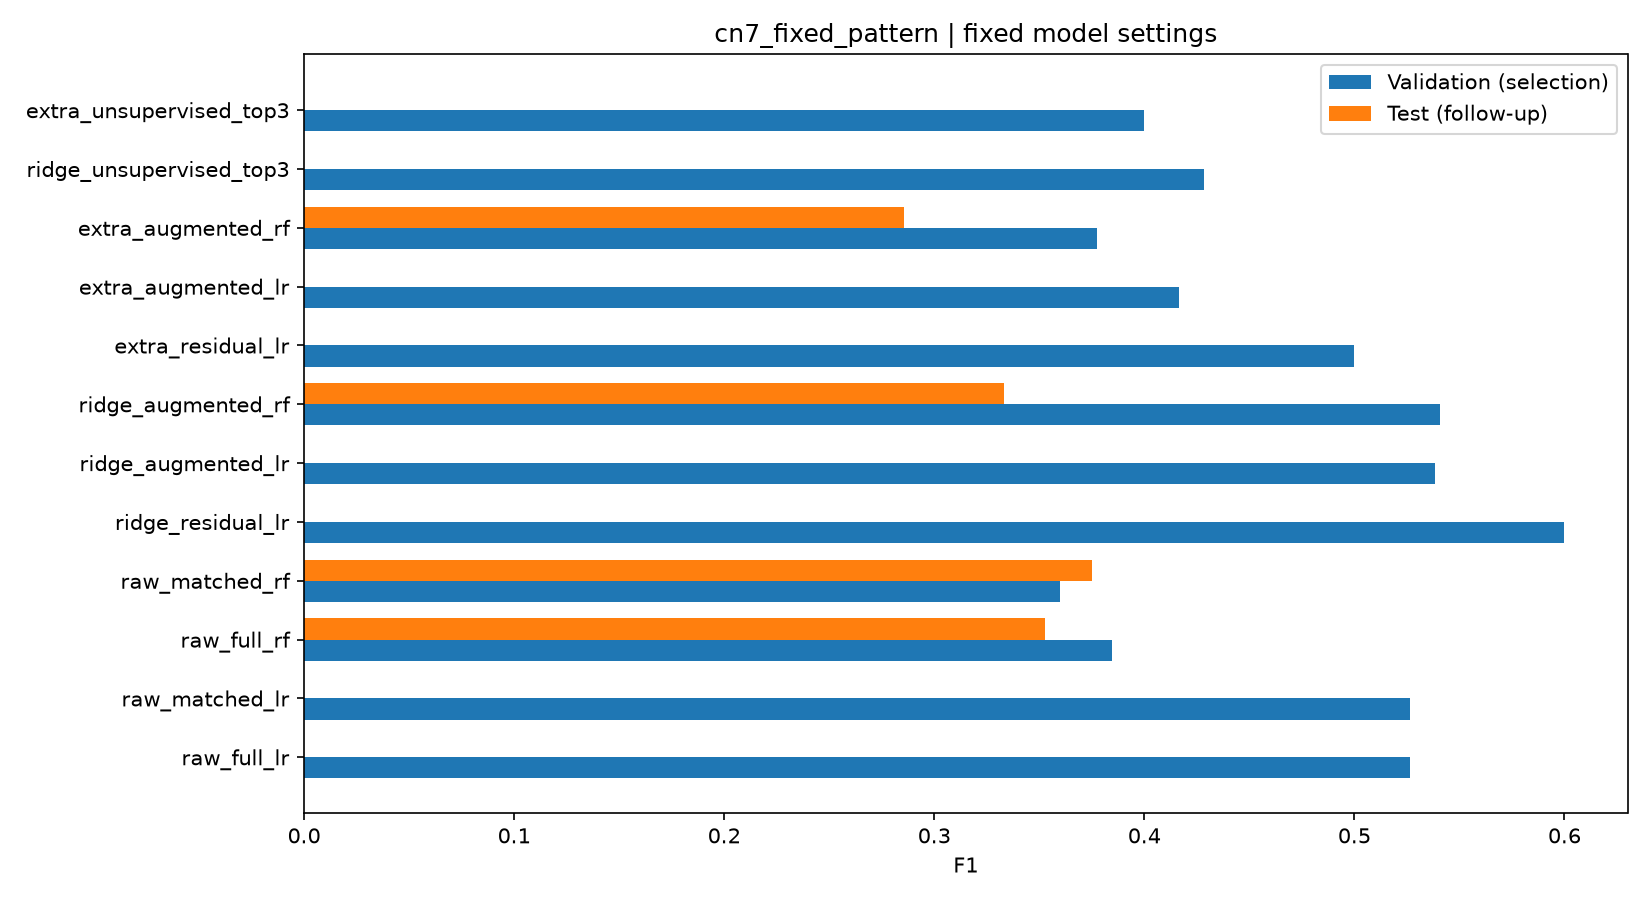

rg3_fixed_pattern


,model,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,extra_residual_lr,0.550688,472,20,7,111,13,341,0.059322,0.35,0.245575,0.101449,0.042456,0.494027
1,extra_unsupervised_top3,1.346397,472,20,4,55,16,397,0.067797,0.20,0.121681,0.101266,0.041962,0.431305
2,ridge_augmented_lr,0.019884,472,20,16,299,4,153,0.050794,0.80,0.661504,0.095522,0.047829,0.492920
3,ridge_residual_lr,0.029205,472,20,17,322,3,130,0.050147,0.85,0.712389,0.094708,0.044651,0.503208
4,extra_augmented_lr,0.005175,472,20,18,346,2,106,0.049451,0.90,0.765487,0.093750,0.038149,0.459403
5,ridge_unsupervised_top3,0.778173,472,20,20,387,0,65,0.049140,1.00,0.856195,0.093677,0.038299,0.465487
6,raw_full_rf,0.084179,472,20,20,421,0,31,0.045351,1.00,0.931416,0.086768,0.039559,0.404314
7,raw_matched_lr,0.034336,472,20,20,429,0,23,0.044543,1.00,0.949115,0.085288,0.031797,0.360288
8,raw_full_lr,0.025181,472,20,20,431,0,21,0.044346,1.00,0.953540,0.084926,0.032190,0.368252
9,ridge_augmented_rf,0.120271,472,20,20,437,0,15,0.043764,1.00,0.966814,0.083857,0.039260,0.446350


,model,selected_on_validation,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,raw_full_lr,False,0.025181,119,5,5,113,0,1,0.042373,1.0,0.991228,0.081301,0.034987,0.314035
1,raw_matched_lr,False,0.034336,119,5,5,113,0,1,0.042373,1.0,0.991228,0.081301,0.032735,0.268421
2,raw_full_rf,False,0.084179,119,5,4,111,1,3,0.034783,0.8,0.973684,0.066667,0.043693,0.398246
3,raw_matched_rf,False,0.072354,119,5,5,114,0,0,0.042017,1.0,1.000000,0.080645,0.041264,0.347368
4,ridge_residual_lr,False,0.029205,119,5,4,92,1,22,0.041667,0.8,0.807018,0.079208,0.043103,0.429825
5,ridge_augmented_lr,False,0.019884,119,5,4,84,1,30,0.045455,0.8,0.736842,0.086022,0.037416,0.361404
6,ridge_augmented_rf,False,0.120271,119,5,4,109,1,5,0.035398,0.8,0.956140,0.067797,0.042203,0.422807
7,extra_residual_lr,True,0.550688,119,5,1,31,4,83,0.031250,0.2,0.271930,0.054054,0.044193,0.447368
8,extra_augmented_lr,False,0.005175,119,5,4,98,1,16,0.039216,0.8,0.859649,0.074766,0.049768,0.461404
9,extra_augmented_rf,False,0.061762,119,5,5,114,0,0,0.042017,1.0,1.000000,0.080645,0.036638,0.335088


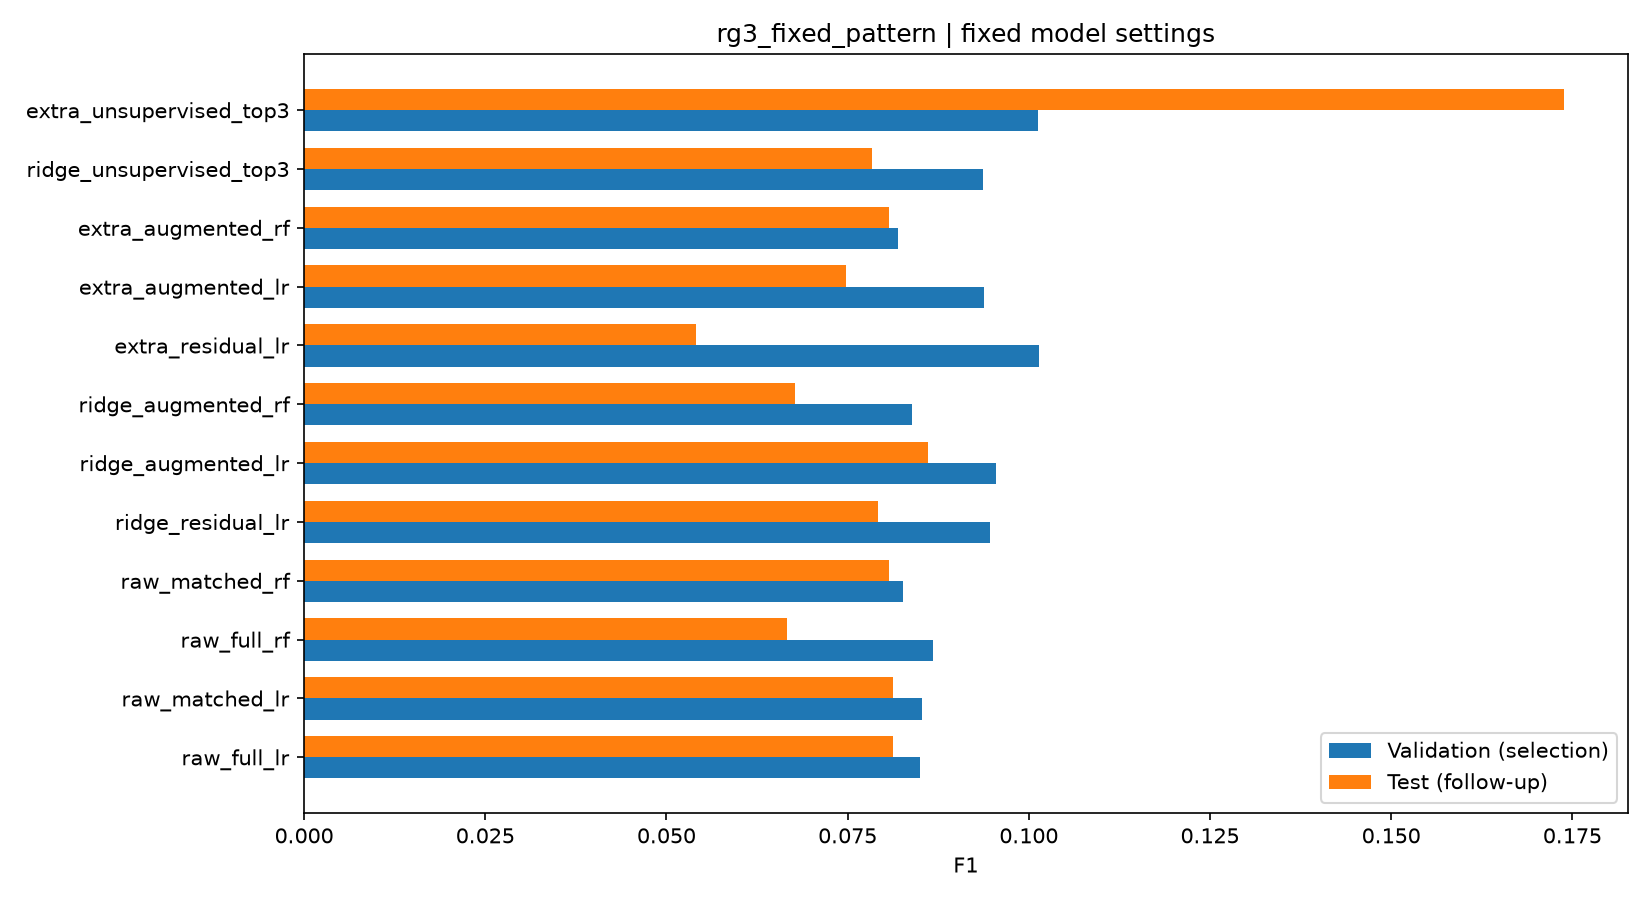

rg3_temporal_assumed


,model,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,ridge_unsupervised_top3,3.955031e+00,233,4,1,9,3,220,0.100000,0.25,0.039301,0.142857,0.059155,0.704148
1,raw_matched_lr,9.996822e-01,233,4,1,16,3,213,0.058824,0.25,0.069869,0.095238,0.026807,0.375546
2,raw_full_rf,4.334199e-01,233,4,1,24,3,205,0.040000,0.25,0.104803,0.068966,0.025311,0.468341
3,raw_matched_rf,4.710001e-01,233,4,1,27,3,202,0.035714,0.25,0.117904,0.062500,0.020382,0.347162
4,ridge_augmented_rf,3.828170e-01,233,4,2,59,2,170,0.032787,0.50,0.257642,0.061538,0.024787,0.554585
5,extra_augmented_rf,4.737845e-01,233,4,1,34,3,195,0.028571,0.25,0.148472,0.051282,0.020838,0.384279
6,extra_unsupervised_top3,4.853289e+00,233,4,2,73,2,156,0.026667,0.50,0.318777,0.050633,0.023408,0.502183
7,ridge_augmented_lr,9.999964e-01,233,4,1,36,3,193,0.027027,0.25,0.157205,0.048780,0.017995,0.325328
8,extra_augmented_lr,9.997132e-01,233,4,3,134,1,95,0.021898,0.75,0.585153,0.042553,0.016688,0.376638
9,extra_residual_lr,1.269371e-15,233,4,4,190,0,39,0.020619,1.00,0.829694,0.040404,0.017387,0.412664


,model,selected_on_validation,threshold,n,positives,TP,FP,FN,TN,precision,recall,FPR,F1,AP,AUC
0,raw_full_lr,False,1.350452e-19,233,5,5,225,0,3,0.021739,1.0,0.986842,0.042553,0.042464,0.452632
1,raw_matched_lr,False,9.996822e-01,233,5,1,7,4,221,0.125000,0.2,0.030702,0.153846,0.065200,0.379825
2,raw_full_rf,False,4.334199e-01,233,5,0,23,5,205,0.000000,0.0,0.100877,0.000000,0.033634,0.633333
3,raw_matched_rf,False,4.710001e-01,233,5,0,22,5,206,0.000000,0.0,0.096491,0.000000,0.026129,0.540351
4,ridge_residual_lr,False,5.465200e-09,233,5,5,228,0,0,0.021459,1.0,1.000000,0.042017,0.041756,0.532456
5,ridge_augmented_lr,False,9.999964e-01,233,5,2,88,3,140,0.022222,0.4,0.385965,0.042105,0.071500,0.528070
6,ridge_augmented_rf,False,3.828170e-01,233,5,1,88,4,140,0.011236,0.2,0.385965,0.021277,0.022774,0.413158
7,extra_residual_lr,False,1.269371e-15,233,5,3,109,2,119,0.026786,0.6,0.478070,0.051282,0.056872,0.528070
8,extra_augmented_lr,False,9.997132e-01,233,5,5,208,0,20,0.023474,1.0,0.912281,0.045872,0.056564,0.521491
9,extra_augmented_rf,False,4.737845e-01,233,5,2,39,3,189,0.048780,0.4,0.171053,0.086957,0.071396,0.655263


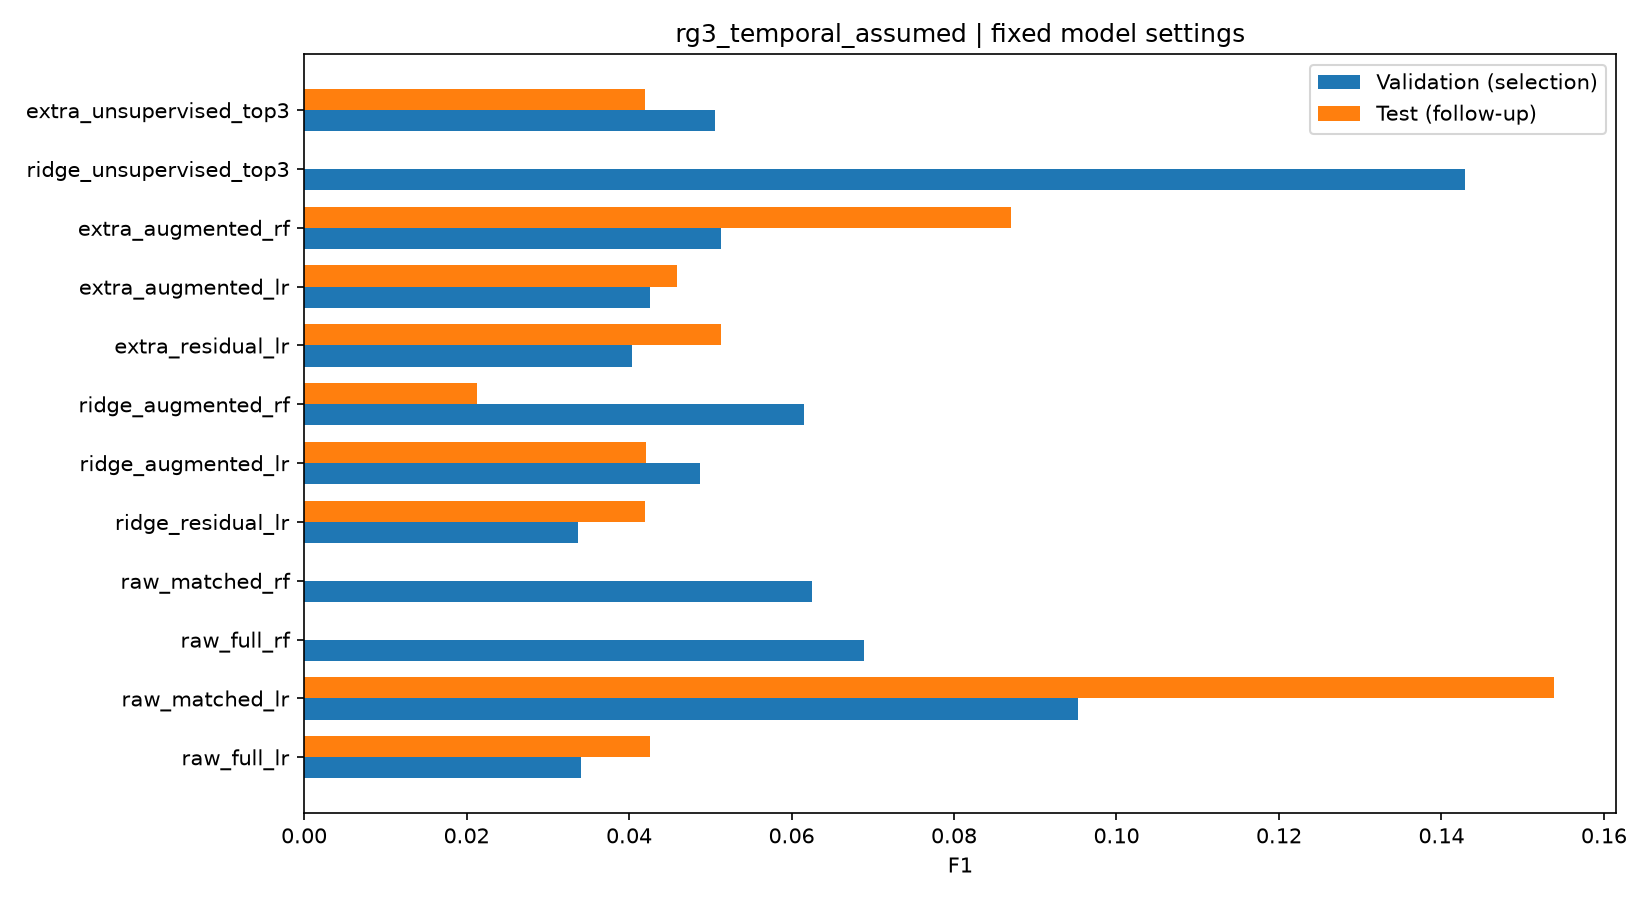

In [3]:
from IPython.display import display, Image
for folder in sorted(result_dir.iterdir()):
    if folder.is_dir() and (folder/'test_comparison.csv').exists():
        print(folder.name)
        display(pd.read_csv(folder/'validation_comparison.csv'))
        display(pd.read_csv(folder/'test_comparison.csv'))
        display(Image(filename=str(folder/'comparison.png')))

## 3. 변수 관계가 실제로 예측되는가?

R²는 정상 참조 자료 내부의 보지 않은 행에서 측정한 관계 예측력입니다. 이것이 높아도 정상·위험 분리력이 높다는 뜻은 아닙니다. test 정상에서의 관계 품질도 함께 봅니다.

cn7_fixed_pattern


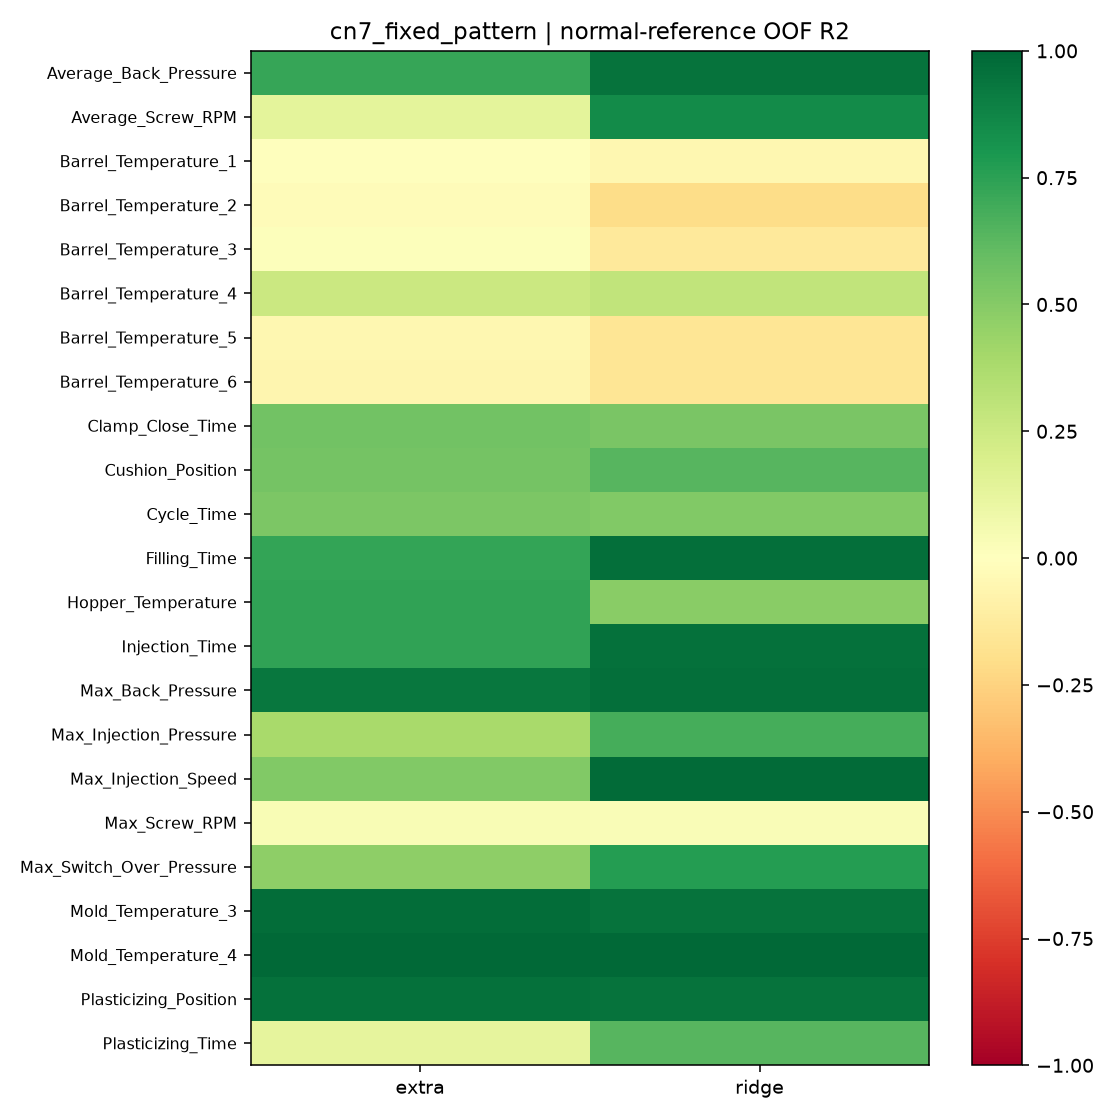

,backend,target,normal_rows,normal_r2,normal_mae
0,ridge,Injection_Time,119,0.959228,0.155873
1,ridge,Filling_Time,119,0.953269,0.156884
2,ridge,Plasticizing_Time,119,0.550939,0.127822
3,ridge,Clamp_Close_Time,119,0.492709,0.501560
4,ridge,Cushion_Position,119,0.708360,0.360399
5,ridge,Plasticizing_Position,119,0.951198,0.136266
6,ridge,Max_Injection_Speed,119,0.975957,0.077768
7,ridge,Average_Screw_RPM,119,0.631768,0.399061
8,ridge,Max_Injection_Pressure,119,0.481039,0.483005
9,ridge,Max_Switch_Over_Pressure,119,0.658061,0.355229


rg3_fixed_pattern


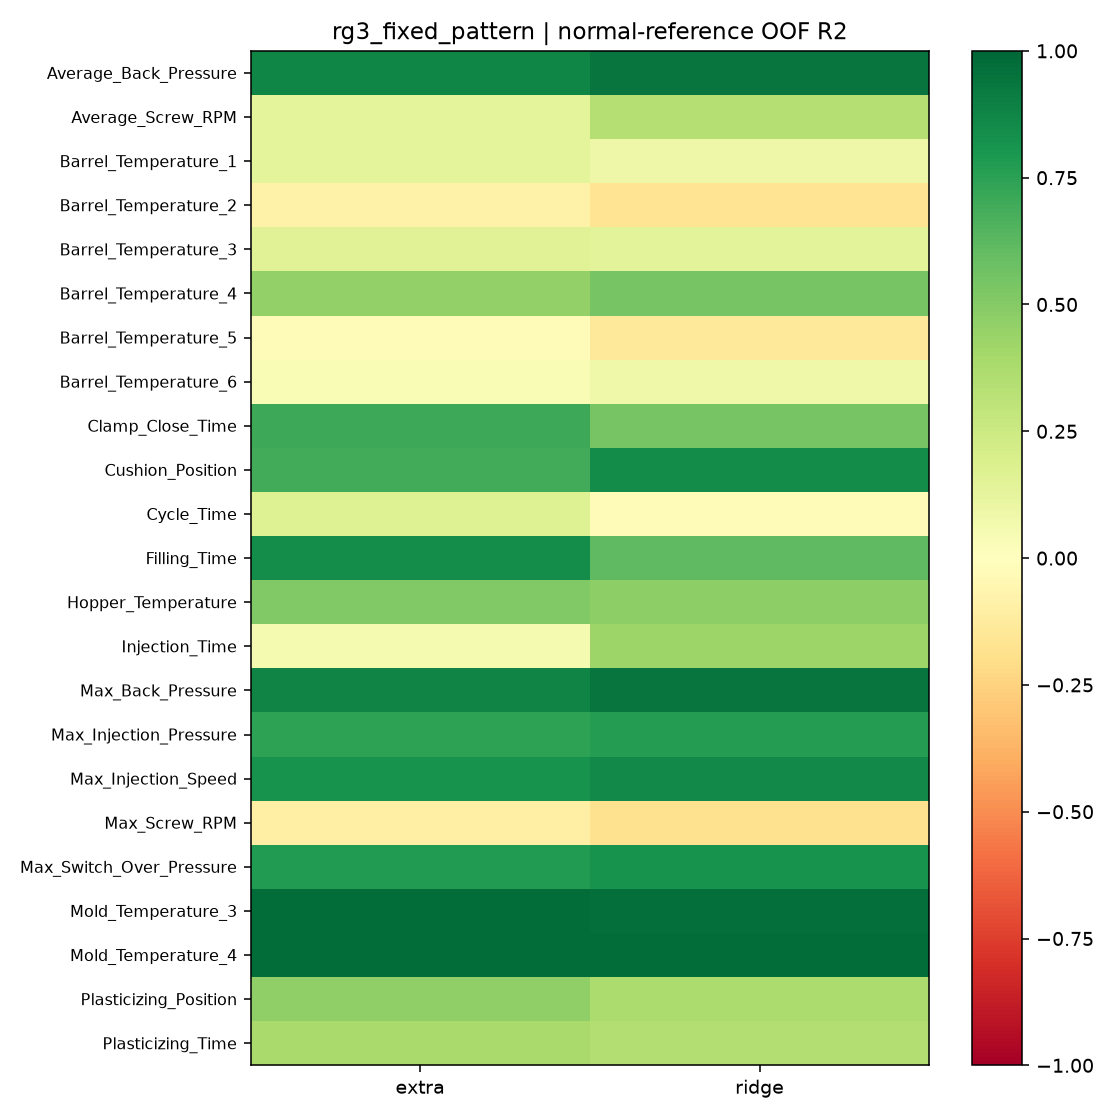

,backend,target,normal_rows,normal_r2,normal_mae
0,ridge,Filling_Time,114,0.409870,0.550673
1,ridge,Plasticizing_Time,114,0.552156,0.515065
2,ridge,Clamp_Close_Time,114,0.482474,0.582586
3,ridge,Cushion_Position,114,0.706602,0.338570
4,ridge,Plasticizing_Position,114,0.341902,0.619487
5,ridge,Max_Injection_Speed,114,0.645255,0.336553
6,ridge,Average_Screw_RPM,114,0.458857,0.613599
7,ridge,Max_Injection_Pressure,114,0.804892,0.339796
8,ridge,Max_Switch_Over_Pressure,114,0.169238,0.317624
9,ridge,Max_Back_Pressure,114,0.810876,0.184134


rg3_temporal_assumed


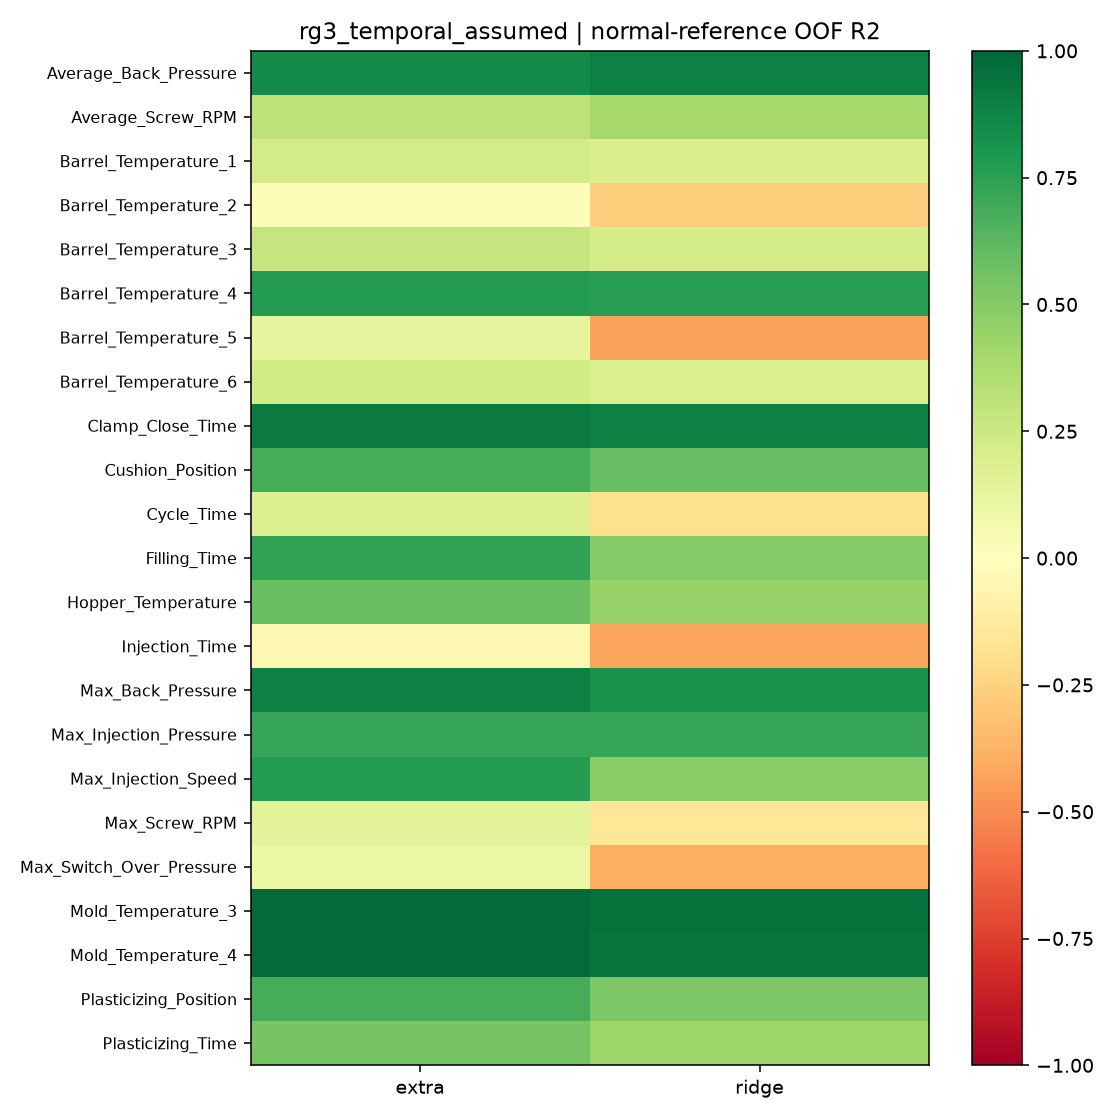

,backend,target,normal_rows,normal_r2,normal_mae
0,ridge,Filling_Time,228,-0.597583,0.458007
1,ridge,Plasticizing_Time,228,-2.671933,0.919657
2,ridge,Clamp_Close_Time,228,0.205114,0.469253
3,ridge,Cushion_Position,228,0.635736,0.402833
4,ridge,Plasticizing_Position,228,-1.363147,0.638138
5,ridge,Max_Injection_Speed,228,0.372536,0.355769
6,ridge,Average_Screw_RPM,228,-0.491689,0.888887
7,ridge,Max_Injection_Pressure,228,-0.478549,0.799509
8,ridge,Max_Back_Pressure,228,0.568326,0.435512
9,ridge,Average_Back_Pressure,228,0.759050,0.233165


In [4]:
for folder in sorted(result_dir.iterdir()):
    if folder.is_dir() and (folder/'relationship_quality.png').exists():
        print(folder.name)
        display(Image(filename=str(folder/'relationship_quality.png')))
        display(pd.read_csv(folder/'test_normal_relationship_quality.csv'))

## 4. 개별 사례의 관계 이탈과 선형 관계식

관계 이탈은 예측의 단서이며 불량 원인이나 물리 법칙이 아닙니다. 실제값/예상값은 제공 데이터 척도입니다.

In [5]:
folder=result_dir/'rg3_fixed_pattern'
examples=pd.read_csv(folder/'test_residual_explanations.csv')
display(examples[examples.label.eq(1)].head(15))
equations=json.loads((folder/'linear_relationship_equations.json').read_text(encoding='utf-8'))
if equations:
    equation=equations[0]
    print(equation['target'], equation['equation'], 'intercept=',equation['intercept'])
    display(pd.DataFrame(equation['terms']))

,row,label,backend,target,observed,expected,scaled_residual,meaning
129,231,1,ridge,Plasticizing_Time,1.753258,0.596973,0.937296,"relationship deviation, NOT causal attribution..."
130,231,1,ridge,Clamp_Close_Time,1.033078,0.167499,0.822055,"relationship deviation, NOT causal attribution..."
131,231,1,ridge,Filling_Time,0.838552,0.188335,0.731049,"relationship deviation, NOT causal attribution..."
198,343,1,ridge,Mold_Temperature_4,-1.454649,-1.190072,-1.218294,"relationship deviation, NOT causal attribution..."
199,343,1,ridge,Max_Injection_Speed,-1.737322,-0.960975,-1.216819,"relationship deviation, NOT causal attribution..."
200,343,1,ridge,Hopper_Temperature,-2.460435,-1.197103,-1.088583,"relationship deviation, NOT causal attribution..."
219,363,1,ridge,Max_Injection_Speed,-1.737322,-0.834146,-1.415607,"relationship deviation, NOT causal attribution..."
220,363,1,ridge,Cushion_Position,-1.911818,-1.186337,-1.119384,"relationship deviation, NOT causal attribution..."
221,363,1,ridge,Mold_Temperature_3,-1.678451,-1.390719,-1.104490,"relationship deviation, NOT causal attribution..."
264,447,1,ridge,Hopper_Temperature,-0.731884,0.160469,-0.768919,"relationship deviation, NOT causal attribution..."


Filling_Time predicted target = intercept + sum(coefficient * (predictor - center) / scale) intercept= 0.020726585684086928


,predictor,coefficient,center,scale
0,Injection_Time,0.015714,0.046996,0.805314
1,Plasticizing_Time,-0.020015,-0.048499,0.966522
2,Cycle_Time,-0.006435,0.026359,0.991003
3,Clamp_Close_Time,0.041136,-0.009845,1.026297
4,Cushion_Position,-0.230469,0.003993,1.050580
5,Plasticizing_Position,-0.035659,0.024783,1.015149
6,Max_Injection_Speed,0.059767,-0.000636,1.020282
7,Max_Screw_RPM,-0.056971,0.041332,1.011946
8,Average_Screw_RPM,-0.057641,-0.081360,0.954394
9,Max_Injection_Pressure,0.401416,0.027659,1.043532


## 5. 재현과 한계

- 원본 CSV 해시와 기존 패턴 분할을 확인했습니다.
- fold별 참조/분류/검증 역할과 선택 manifest를 저장했습니다.
- 저장 모델 재로딩 후 점수 일치를 확인했습니다.
- 테스트 위험 사례 수가 적고 기존에 관찰한 자료입니다.
- 비라벨 파일에 대한 성능이나 운영 가능성을 주장하지 않습니다.
- 관계식이 정상 관계를 설명하는지와 그 잔차가 불량을 찾는지는 별개입니다.

In [6]:
verification=json.loads((result_dir/'run_verification.json').read_text(encoding='utf-8'))
print('실행 완료:',verification['status'])
print('원본 보존:',verification['original_csv_unchanged'])
print('실험 실행 시간(초):',round(verification['elapsed_seconds'],2))

실행 완료: completed
원본 보존: True
실험 실행 시간(초): 55.97
